#### 0. Install dependencies

In [9]:
import numpy as np
import h5py
import importlib

from gtda.plotting import plot_point_cloud
from gudhi import AlphaComplex

import pickle
from pathlib import Path

#### 2. Plot

In [2]:
samples = {}
train_file = "./data/MNIST3d/train_point_clouds.h5"

with h5py.File(train_file,"r") as hf:
  for key in hf.keys(): # key = id
    group = hf[key]
    label = int(group.attrs["label"])

    if (label not in samples):  # take 1 instance of each digit
      points = group["points"][:] # (N, 3)  x, y, z
      samples[label] = points

      if len(samples) == 10:
        break


In [3]:
# sorting is optional i just think it looks better this way
sorted_samples = dict(sorted(samples.items()))
plot_point_cloud(sorted_samples[0]) # change number in brackets to plot different digits

#### 3. Нормализация
Согласно документации датасета, все облака точек должны быть нормализованы. Проверим это, собрав статистику по каждой цифре отдельно и по всем цифрам сразу.

In [ ]:
import utils.stat
importlib.reload(utils.stat)

class_stats, global_stats = utils.stat.compute_statistics(train_file)

In [12]:
class_stats

num_points                                      range_x        range_y  \
      num_clouds        mean        std    min    max    mean    std    mean   
label                                                                          
0            479  27806.3674  2404.0861  19050  35400  0.3000  0.000  0.9065   
1            563  13510.6572  2211.8518   9250  26850  0.3000  0.000  0.4898   
2            488  24701.2295  3273.3208  14600  32400  0.3000  0.000  0.9172   
3            493  25364.5030  3462.8836  14550  33550  0.3000  0.000  0.8404   
4            535  21927.7570  2667.0957  14950  28300  0.3000  0.000  0.8257   
5            434  24189.2857  3614.6889  15900  35600  0.3000  0.000  0.9144   
6            501  22882.1357  3531.0587  14450  37300  0.3000  0.000  0.7500   
7            550  20357.0909  2637.8022  13150  27600  0.3001  0.001  0.8112   
8            462  25543.9394  3563.1286  15250  38200  0.3000  0.000  0.7985   
9            495  21867.9798  2837.9709  12100  30600  0.3000  0.000  0.7201   

              range_z          
          std    mean     std  
label                          
0      0.1138  0.9827  0.0532  
1      0.2016  0.9996  0.0087  
2      0.1172  0.9553  0.0883  
3      0.1393  0.9941  0.0288  
4      0.1400  0.9942  0.0266  
5      0.1223  0.9461  0.0928  
6      0.1477  0.9954  0.0284  
7      0.1433  0.9916  0.0366  
8      0.1462  0.9936  0.0342  
9      0.1336  0.9986  0.0126

Наиболее заметное различие наблюдается в количестве точек: цифры 0 и 8 представлены наиболее плотными облаками, в то время как цифра 1 содержит существенно меньше точек.
По пространственным характеристикам все объекты имеют практически идентичный диапазон по оси X, что обусловлено особенностями генерации датасета. В то же время по осям Y и Z наблюдаются выраженные класс-специфичные различия. Цифра 1 характеризуется вытянутостью (относительно узкий диапазон по Y), в то время как цифры 0, 2 и 5 имеют более сбалансированные пропорции. Классы демонстрируют диапазон по Z близкий к 1.0.

In [13]:
global_stats

,mean,std,min,max
num_points,22600.0900,4895.4854,9250.00,38200.0000
range_x,0.3000,0.0003,0.30,0.3158
range_y,0.7915,0.1899,0.15,1.0000
range_z,0.9859,0.0509,0.50,1.0000
label,4.4670,2.8722,0.00,9.0000


In [14]:
# subsample the original dataset

def subsample_dataset(max_samples_per_class=10):
  point_clouds = []
  labels = []

  with h5py.File(train_file, "r") as hf:
      for key in hf.keys(): # indices
          group = hf[key] # point cloud
          label = int(group.attrs["label"]) # labels

          if sum(1 for l in labels if l == label) >= max_samples_per_class:
              continue

          points = group["points"][:].astype(np.float64)

          point_clouds.append(points)
          labels.append(label)

          if len(point_clouds) >= 10 * max_samples_per_class:
              break

  labels = np.array(labels)
  return point_clouds, labels

In [15]:
point_clouds = subsample_dataset(max_samples_per_class=50)[0]
labels = subsample_dataset(max_samples_per_class=50)[1]
max([cloud.shape[0] for cloud in point_clouds])

33800

point clouds contain way too many points so the simplicial complexes will not calculate in reasonable time. therefore we subsample the points

In [40]:
rng = np.random.default_rng(seed=42)

subsampled_point_clouds = []
n_points = 1000

point_clouds_to_subsample, lables_subsampled = subsample_dataset(1)

for pc in subsample_dataset(1)[0]:
    if pc.shape[0] <= n_points:
        subsampled_point_clouds.append(pc)
    else:
        idx = rng.choice(pc.shape[0], n_points, replace=False)
        subsampled_point_clouds.append(pc[idx])
subsampled_point_clouds = np.array(subsampled_point_clouds)

plot_point_cloud(subsampled_point_clouds[3])

#### 4. Persistance diagrams

In [17]:
from joblib import Parallel, delayed
from tqdm import tqdm

In [18]:
def process_cloud(cloud, lifetime_thresh=1e-8, max_alpha_square=10):
    ac = AlphaComplex(points=cloud)

    st = ac.create_simplex_tree(
        max_alpha_square=max_alpha_square
    )

    persistence = st.persistence(homology_coeff_field=2)

    persistence = [
        (dim, pair)
        for (dim, pair) in persistence
        if np.isinf(pair[1]) or pair[1] - pair[0] > lifetime_thresh
    ]

    return st, persistence


def build_diagrams(
    point_clouds,
    lifetime_thresh=1e-8,
    max_alpha_square=10,
    n_jobs=-1
):

    trees = []
    diagrams = []

    results = Parallel(n_jobs=n_jobs)(
		delayed(process_cloud)(
        	cloud,
        	lifetime_thresh,
        	max_alpha_square
    	)
    	for cloud in tqdm(point_clouds, desc="Processing clouds")
	)

    trees, diagrams = zip(*results)

    return trees, diagrams

In [62]:
trees, diagrams = build_diagrams(point_clouds)

trees_sub, diagrams_sub = build_diagrams(subsampled_point_clouds)

Processing clouds: 100%|██████████| 10/10 [00:00<00:00, 681.59it/s]


#### 5. Save/load diagrams

In [63]:
trees_path = Path("./data/tda/simplex_trees_gudhi.pkl")
diagrams_path = Path("./data/tda/persistence_diagrams_gudhi.pkl")

subsampled_trees_path = Path("./data/tda/subsampled_simplex_trees_gudhi.pkl")
subsampled_diagrams_path = Path("./data/tda/subsampled_persistence_diagrams_gudhi.pkl")

In [64]:
def save_tree_diagram(diagrams_path, diagrams, trees_path=None, trees=None):
  if(trees_path):
    with open(trees_path, "wb") as f:
      pickle.dump(trees, f)
    print(f"Trees saved to {trees_path}")

  with open(diagrams_path, "wb") as f:
    pickle.dump(diagrams, f)

  print(f"Diagrams saved to {diagrams_path}")

def load_object(path):
  with open(path, "rb") as f:
    loaded = pickle.load(f)

  print(f"Loaded {len(loaded)} objects")
  return loaded

In [65]:
save_tree_diagram(diagrams_path, diagrams, trees_path, trees)
save_tree_diagram(subsampled_diagrams_path, diagrams_sub, subsampled_trees_path, trees_sub)

Trees saved to data\tda\simplex_trees_gudhi.pkl
Diagrams saved to data\tda\persistence_diagrams_gudhi.pkl
Trees saved to data\tda\subsampled_simplex_trees_gudhi.pkl
Diagrams saved to data\tda\subsampled_persistence_diagrams_gudhi.pkl


In [66]:
diagrams_loaded = load_object(diagrams_path)
subsampled_diagrams_loaded = load_object(subsampled_diagrams_path)

Loaded 500 objects
Loaded 10 objects


#### 6. Plot diagrams

In [25]:
import gudhi as gd
from matplotlib import pyplot as plt

def plot_persistance(diagrams, labels, digit):
  idx = np.where(labels == digit)[0][0]
  gd.plot_persistence_diagram(diagrams[idx], legend = True)
  plt.show()

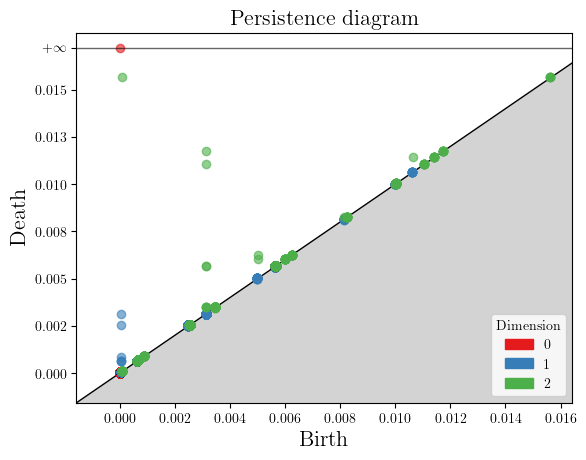

In [26]:
plot_persistance(diagrams_loaded, labels, 8)

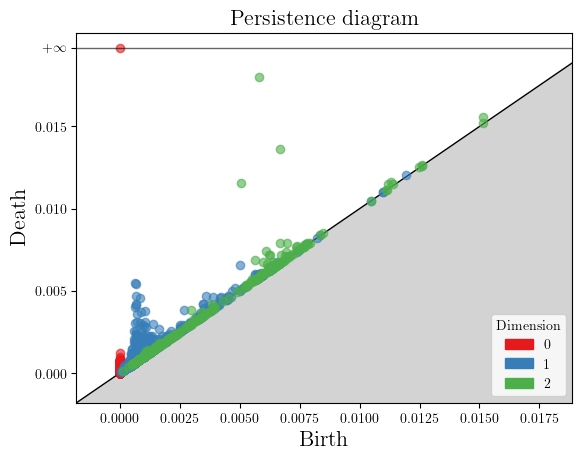

In [27]:
plot_persistance(subsampled_diagrams_loaded, lables_subsampled, 8)

#### 7. Vectorization

In [67]:
trees_loaded = load_object(trees_path)

MemoryError: 

In [69]:
for tree in trees:
  tree.persistence()

In [73]:
from gudhi.representations import Landscape

LS = Landscape(
    num_landscapes=5,
    resolution=1000,
    )
L = LS.fit_transform([trees[3].persistence_intervals_in_dimension(1)])

plt.plot(L[0][:1000])
plt.plot(L[0][1000:2000])
plt.title("Landscape")
plt.show()

MemoryError: Unable to allocate 118. MiB for an array with shape (1000, 15401) and data type float64

In [71]:
L

array([[0., 0., 0., ..., 0., 0., 0.]])

In [60]:
L[0].shape

(5000,)